In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
import statsmodels.api as sm

pd.set_option("display.max_columns", None)

df = pd.read_csv("pakistan_development_processed.csv")
df["Year"] = pd.to_numeric(df["Year"])

df.head()

,Year,GDP Growth,GDP per Capita,Inflation,Unemployment,Population,Population Growth,Urban Population,Life Expectancy,Access to Electricity,Renewable Energy
0,1960,NaN,82.024100,6.947368,NaN,45709310,NaN,22.299698,44.101,NaN,NaN
1,1961,5.987346,87.777825,1.640420,NaN,46921277,2.616924,22.632127,44.956,NaN,NaN
2,1962,4.482859,89.503953,-0.516462,NaN,48156128,2.597716,22.934215,45.850,NaN,NaN
3,1963,8.688832,93.650873,1.456488,NaN,49447776,2.646868,23.208181,46.761,NaN,NaN
4,1964,7.569757,102.459764,4.179587,NaN,50799999,2.697925,23.460517,47.831,NaN,NaN


In [2]:
analysis_df = df[
    ["GDP per Capita", "Life Expectancy"]
].dropna()

correlation, p_value = pearsonr(
    analysis_df["GDP per Capita"],
    analysis_df["Life Expectancy"]
)

print("Pearson correlation:", correlation)
print("p-value:", p_value)
print("Number of observations:", len(analysis_df))

Pearson correlation: 0.8511287224671895
p-value: 2.7279836730747664e-19
Number of observations: 65


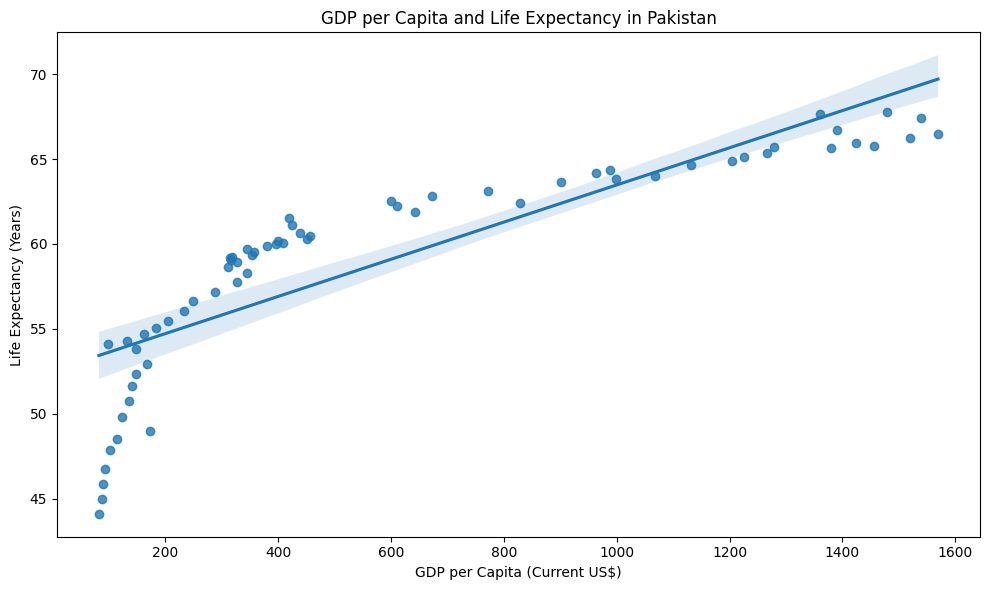

In [3]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=analysis_df,
    x="GDP per Capita",
    y="Life Expectancy"
)

plt.title("GDP per Capita and Life Expectancy in Pakistan")
plt.xlabel("GDP per Capita (Current US$)")
plt.ylabel("Life Expectancy (Years)")

plt.tight_layout()
plt.show()

In [4]:
X = analysis_df[["GDP per Capita"]]
y = analysis_df["Life Expectancy"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Life Expectancy   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.720
Method:                 Least Squares   F-statistic:                     165.6
Date:                Thu, 01 Oct 2026   Prob (F-statistic):           2.73e-19
Time:                        06:03:40   Log-Likelihood:                -168.25
No. Observations:                  65   AIC:                             340.5
Df Residuals:                      63   BIC:                             344.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             52.5299      0.647     81.

In [5]:
multiple_df = df[
    [
        "Life Expectancy",
        "GDP per Capita",
        "Urban Population",
        "Access to Electricity"
    ]
].dropna()

X = multiple_df[
    [
        "GDP per Capita",
        "Urban Population",
        "Access to Electricity"
    ]
]

y = multiple_df["Life Expectancy"]

X = sm.add_constant(X)

multiple_model = sm.OLS(y, X).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Life Expectancy   R-squared:                       0.967
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                     223.8
Date:                Thu, 01 Oct 2026   Prob (F-statistic):           3.72e-17
Time:                        06:03:40   Log-Likelihood:                -9.3261
No. Observations:                  27   AIC:                             26.65
Df Residuals:                      23   BIC:                             31.84
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    42.66

In [6]:
print("Observations used in multiple regression:", len(multiple_df))

Observations used in multiple regression: 27


In [7]:
with open("regression_results.txt", "w") as file:
    file.write("Simple OLS Regression\n")
    file.write("=====================\n\n")
    file.write(str(model.summary()))

    file.write("\n\n\nMultiple OLS Regression\n")
    file.write("=======================\n\n")
    file.write(str(multiple_model.summary()))

print("Regression results saved.")

Regression results saved.
